In [2]:
from labdata.schema import DecisionTask  # type: ignore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

[2026-02-09 18:05:09,216][INFO]: Connecting rojasbowe@churchland-data.cmojfwfr0b9t.us-west-2.rds.amazonaws.com:3306
[2026-02-09 18:05:09,815][INFO]: Connected rojasbowe@churchland-data.cmojfwfr0b9t.us-west-2.rds.amazonaws.com:3306


In [10]:
from chipmunk import Chipmunk

Chipmunk() & 'subject_name = "GRB058"'

subject_name unique mouse id,session_name session identifier,dataset_name,duration (seconds),setting_modalities,setting_left_reward_volume,setting_right_reward_volume,setting_prob_audio,setting_prob_vision,setting_high_rate_side,setting_strict_choice 1: no do overs 0: allow changing choice # ReviseChoiceFlag,setting_free_initiation 1: animal can initiate 0: initiation time limit # PacedFlag,setting_task_mode


In [2]:
# TODO: incorporate the session filter for the full data dataframe. right now, the multisession graphs are ignoring this
# TODO: change the first plot to be a bar graph where it shows for each intensity in green the number of correct trials, in red the incorrect, and in gray if they were early withdrawals

In [2]:
mouse = "GRB050"
session = "20260206"
base_query = DecisionTask.TrialSet() & f"subject_name = '{mouse}'"
data = pd.DataFrame(base_query)
ses_back = 10 if len(data) >= 10 else len(data)
data = data.tail(ses_back)
sesdata = pd.DataFrame(base_query & f"session_name LIKE '{session}%'")
session_name = sesdata.session_name.values[0]

ew_rate = []
for ses in data.itertuples(index=False):
    ew_trials = ~(
        np.isin(np.array(ses.response_values), [-1, 1])
    )  # check if this includes no choice trials
    ew_rate.append((ew_trials).sum() / ew_trials.shape[0])

valid_trials = sesdata.response_values.apply(lambda x: np.isin(x, [-1, 1])).values[
    0
]  # removing early withdrawal trials
stims = sesdata.intensity_values.values[0][valid_trials]
responses = np.array(sesdata.response_values.values[0])[
    valid_trials
]  # this one is saved as a list in the database
correct = sesdata.correct_values.values[0][valid_trials]
react_times = sesdata.reaction_times.values[0][valid_trials]
react_times = react_times[react_times < 2]

unique_stims = np.unique(sesdata.intensity_values.values[0])
frac_correct = []
p_right = []
for ustim in unique_stims:
    mask = stims == ustim
    right_mask = responses[mask] == 1
    frac_correct.append(correct[mask].sum() / correct[mask].shape[0])
    p_right.append(right_mask.sum() / right_mask.shape[0])

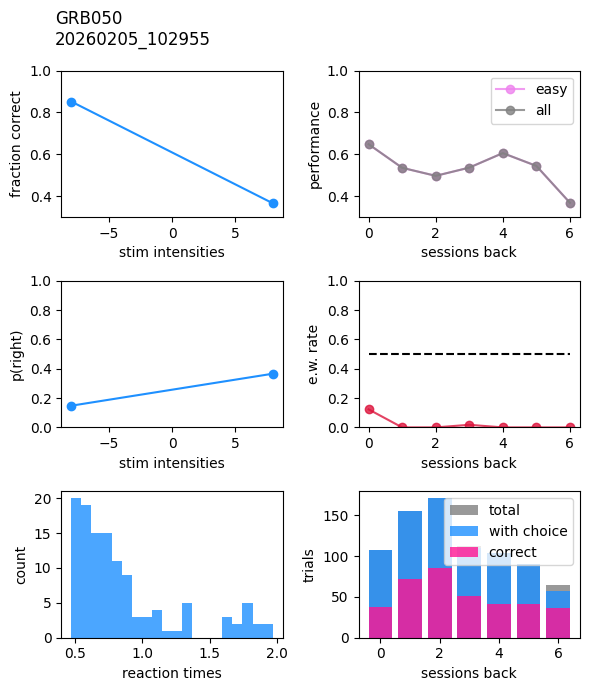

In [6]:
fig, ax = plt.subplots(3, 2, figsize=(6, 7))

### fraction correct per stim ###
ax[0, 0].plot(unique_stims, frac_correct, "o-", color="dodgerblue")
ax[0, 0].set_xlabel("stim intensities")
ax[0, 0].set_ylabel("fraction correct")
ax[0, 0].set_ylim((0.3, 1))

### p(right) per stim ###
ax[1, 0].plot(unique_stims, p_right, "o-", color="dodgerblue")
ax[1, 0].set_xlabel("stim intensities")
ax[1, 0].set_ylabel("p(right)")
ax[1, 0].set_ylim((0, 1))

### performance on easy trials ###
xvalues = np.arange(0, ses_back, 1)
ax[0, 1].plot(
    xvalues,
    data["performance_easy"][::-1],
    color="violet",
    marker="o",
    linestyle="-",
    label="easy",
    alpha=0.8,
)
ax[0, 1].plot(
    xvalues,
    data["performance"][::-1],
    color="grey",
    marker="o",
    linestyle="-",
    label="all",
    alpha=0.8,
)
ax[0, 1].set_ylabel("performance")
ax[0, 1].set_xlabel("sessions back")
ax[0, 1].legend()
ax[0, 1].set_ylim((0.3, 1))

### early withdrawal rate ###
ax[1, 1].hlines(0.5, xvalues[0], xvalues[-1], color="k", linestyle="--")
ax[1, 1].plot(xvalues, ew_rate, color="crimson", marker="o", alpha=0.8)
ax[1, 1].set_xlabel("sessions back")
ax[1, 1].set_ylabel("e.w. rate")
ax[1, 1].set_ylim([0, 1])

### reaction times ###
ax[2, 0].hist(react_times, bins=20, color="dodgerblue", alpha=0.8)
ax[2, 0].set_xlabel("reaction times")
ax[2, 0].set_ylabel("count")

### trial counts ###
ax[2, 1].bar(xvalues, data["n_trials"][::-1], color="grey", label="total", alpha=0.8)
ax[2, 1].bar(
    xvalues,
    data["n_with_choice"][::-1],
    color="dodgerblue",
    label="with choice",
    alpha=0.8,
)
ax[2, 1].bar(
    xvalues,
    data["n_correct"][::-1],
    color="deeppink",
    label="correct",
    alpha=0.8,
)
ax[2, 1].set_ylabel("trials")
ax[2, 1].set_xlabel("sessions back")
ax[2, 1].set_xticks(xvalues[::2])
ax[2, 1].legend()

fig.suptitle(
    f"{sesdata.subject_name.values[0]}\n{sesdata.session_name.values[0]}",
    x=0.1,
    ha="left",
)
plt.tight_layout()
plt.show()
# fig.savefig(f"/Users/gabriel/Downloads/{mouse}_{session_name}_perf_summary.png")